# 07 - Final Dashboard

Build visual summary dashboard (plotly + mplsoccer).

Saved rsi_play_final.gif


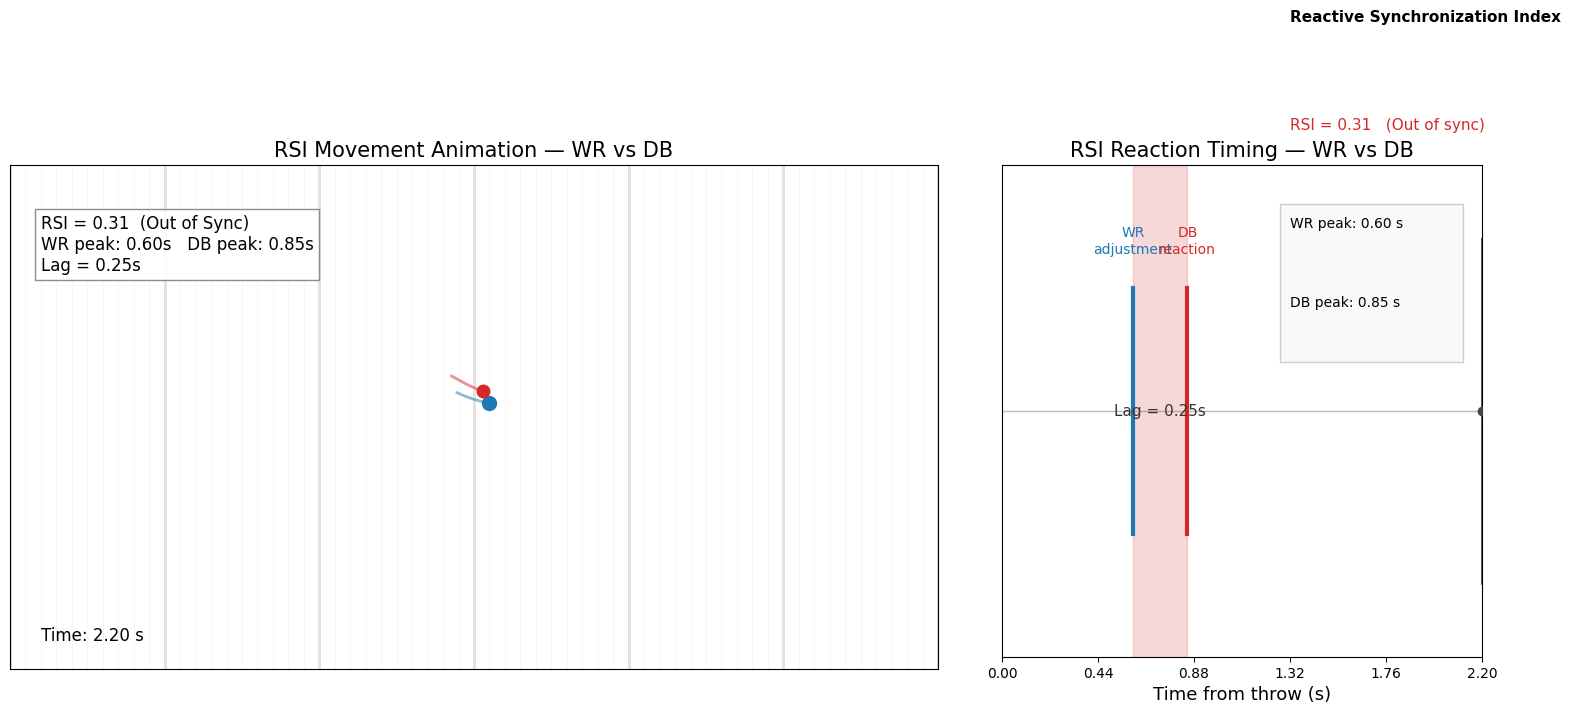

In [ ]:
# rsi_visualization_final.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

# -----------------------------
# 1. Dummy RSI Data (single play)
# -----------------------------
t = np.linspace(0, 2.2, 22)            # times (seconds)
x_wr = 20 + 5 * t                      # dummy WR x (yards)
y_wr = 30 + 2 * np.sin(2 * t)          # dummy WR y
x_db = 20 + 4.8 * t
y_db = 31 + 2.2 * np.sin(2 * (t - 0.2))

t_wr_peak = 0.6
t_db_peak = 0.85
lag = abs(t_wr_peak - t_db_peak)
RSI = 0.31

i_wr_peak = int(np.argmin(np.abs(t - t_wr_peak)))
i_db_peak = int(np.argmin(np.abs(t - t_db_peak)))

# -----------------------------
# 2. Figure & Axes Setup
# -----------------------------
FIG_W, FIG_H = 16, 6
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)

# left: field panel
ax_field = fig.add_axes([0.04, 0.08, 0.58, 0.84])

# right: timeline panel
ax_timeline = fig.add_axes([0.66, 0.10, 0.30, 0.82])

# -----------------------------
# 3. Left panel content
# -----------------------------
ax_field.set_xlim(0, 60)
ax_field.set_ylim(0, 53.3)
ax_field.set_xticks([])
ax_field.set_yticks([])
ax_field.set_title("RSI Movement Animation — WR vs DB", fontsize=15)

# subtle yardlines
for x in range(0, 61, 10):
    ax_field.axvline(x, color="#DDDDDD", lw=2, zorder=0)
for x in range(0, 61):
    ax_field.axvline(x, color="#EEEEEE", lw=0.6, alpha=0.6, zorder=0)

# artists
wr_dot, = ax_field.plot([], [], "o", markersize=10, color="#1f77b4", zorder=5)
db_dot, = ax_field.plot([], [], "o", markersize=9, color="#d62728", zorder=5)
wr_trail, = ax_field.plot([], [], "-", lw=2, color="#1f77b4", alpha=0.5, zorder=4)
db_trail, = ax_field.plot([], [], "-", lw=2, color="#d62728", alpha=0.5, zorder=4)
wr_halo, = ax_field.plot([], [], "o", markersize=20, alpha=0.25, color="#1f77b4", zorder=3)
db_halo, = ax_field.plot([], [], "o", markersize=20, alpha=0.25, color="#d62728", zorder=3)
rsi_text = ax_field.text(2, 48,
    f"RSI = {RSI:.2f}  (Out of Sync)\nWR peak: {t_wr_peak:.2f}s   DB peak: {t_db_peak:.2f}s\nLag = {lag:.2f}s",
    fontsize=12, ha='left', va='top', bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9), zorder=10)
time_text = ax_field.text(2, 3, "", fontsize=12, zorder=10)

# -----------------------------
# 4. Right panel content (explicit artists)
# -----------------------------
ax_timeline.set_xlim(0, t[-1])
ax_timeline.set_ylim(0, 1)
ax_timeline.set_yticks([])
ax_timeline.set_xlabel("Time from throw (s)", fontsize=13)
ax_timeline.set_title("RSI Reaction Timing — WR vs DB", fontsize=15)

# baseline (plot a visible baseline line and keep artist)
baseline_y = 0.5
baseline_line, = ax_timeline.plot([t[0], t[-1]], [baseline_y, baseline_y], color="#BBBBBB", lw=1, zorder=1)

# Peak lines (create explicit Line2D artists using plot)
wr_peak_line, = ax_timeline.plot([t_wr_peak, t_wr_peak], [0.25, 0.75], color="#1f77b4", lw=3, zorder=5)
db_peak_line, = ax_timeline.plot([t_db_peak, t_db_peak], [0.25, 0.75], color="#d62728", lw=3, zorder=5)

# Peak labels (use data coords, add as text artists)
wr_peak_text = ax_timeline.text(t_wr_peak, 0.82, "WR\nadjustment", color="#1f77b4", ha='center', fontsize=10, zorder=6)
db_peak_text = ax_timeline.text(t_db_peak, 0.82, "DB\nreaction", color="#d62728", ha='center', fontsize=10, zorder=6)

# Shaded lag band as Rectangle in data coordinates
lag_min, lag_max = min(t_wr_peak, t_db_peak), max(t_wr_peak, t_db_peak)
if lag < 0.10:
    band_color = (44/255, 160/255, 44/255, 0.18)
elif lag < 0.25:
    band_color = (255/255, 127/255, 14/255, 0.18)
else:
    band_color = (214/255, 39/255, 40/255, 0.18)
# Rectangle(xy=(left, bottom), width, height) bottom at 0, height 1
lag_rect = Rectangle((lag_min, 0), lag_max - lag_min, 1.0, color=band_color, zorder=2)
ax_timeline.add_patch(lag_rect)

# center lag label (data coord)
lag_label = ax_timeline.text((lag_min + lag_max) / 2, baseline_y, f"Lag = {lag:.2f}s",
                            fontsize=11, ha='center', va='center', color="#333333", zorder=7)

# Cursor line + cursor dot as explicit Line2D artists (update during animation)
cursor_line, = ax_timeline.plot([t[0], t[0]], [0.15, 0.85], color="#444444", lw=2, zorder=9)
cursor_dot, = ax_timeline.plot([], [], "o", color="#444444", markersize=6, zorder=10)

# Make x ticks nice and visible
ax_timeline.set_xticks(np.linspace(0, t[-1], min(6, len(t))))
ax_timeline.tick_params(axis='x', labelsize=10)

# RSI summary box: draw as Rectangle in axes fraction coords using transform=ax_timeline.transAxes
box_x, box_y, box_w, box_h = 0.58, 0.60, 0.38, 0.32
summary_box = Rectangle((box_x, box_y), box_w, box_h, transform=ax_timeline.transAxes,
                        facecolor="#F9F9F9", edgecolor="#CCCCCC", zorder=12)
ax_timeline.add_patch(summary_box)
summary_title = ax_timeline.text(box_x + 0.02, box_y + 0.70, "Reactive Synchronization Index",
                                transform=ax_timeline.transAxes, fontsize=11, fontweight='bold', va='center', zorder=13)
rsi_color = "#2ca02c" if RSI >= 0.75 else ("#ff7f0e" if RSI >= 0.5 else "#d62728")
summary_val = ax_timeline.text(box_x + 0.02, box_y + 0.48, f"RSI = {RSI:.2f}   ({'High Sync' if RSI>=0.75 else ('Moderate' if RSI>=0.5 else 'Out of sync')})",
                              transform=ax_timeline.transAxes, fontsize=11, color=rsi_color, va='center', zorder=13)
summary_wr = ax_timeline.text(box_x + 0.02, box_y + 0.28, f"WR peak: {t_wr_peak:.2f} s", transform=ax_timeline.transAxes, fontsize=10, va='center', zorder=13)
summary_db = ax_timeline.text(box_x + 0.02, box_y + 0.12, f"DB peak: {t_db_peak:.2f} s", transform=ax_timeline.transAxes, fontsize=10, va='center', zorder=13)

# -----------------------------
# 5. Animation update function
# -----------------------------
def update(frame):
    # Left
    wr_dot.set_data([x_wr[frame]], [y_wr[frame]])
    db_dot.set_data([x_db[frame]], [y_db[frame]])

    start = max(0, frame - 4)
    wr_trail.set_data(x_wr[start:frame+1], y_wr[start:frame+1])
    db_trail.set_data(x_db[start:frame+1], y_db[start:frame+1])

    wr_halo.set_data([x_wr[frame]] if frame == i_wr_peak else [], [y_wr[frame]] if frame == i_wr_peak else [])
    db_halo.set_data([x_db[frame]] if frame == i_db_peak else [], [y_db[frame]] if frame == i_db_peak else [])

    time_text.set_text(f"Time: {t[frame]:.2f} s")

    # Right: move cursor
    cursor_line.set_data([t[frame], t[frame]], [0.15, 0.85])
    cursor_dot.set_data([t[frame]], [baseline_y])

    # Return all artists that changed (important for blit=True)
    return [
        wr_dot, db_dot, wr_trail, db_trail, wr_halo, db_halo, time_text,
        cursor_line, cursor_dot, wr_peak_line, db_peak_line, lag_rect, lag_label,
        summary_box, summary_title, summary_val, summary_wr, summary_db
    ]


# -----------------------------
# 6. Animate & save
# -----------------------------
anim = FuncAnimation(fig, update, frames=len(t), interval=120, blit=True)
anim.save("rsi_play_final.gif", writer=PillowWriter(fps=10))
print("Saved rsi_play_final.gif")


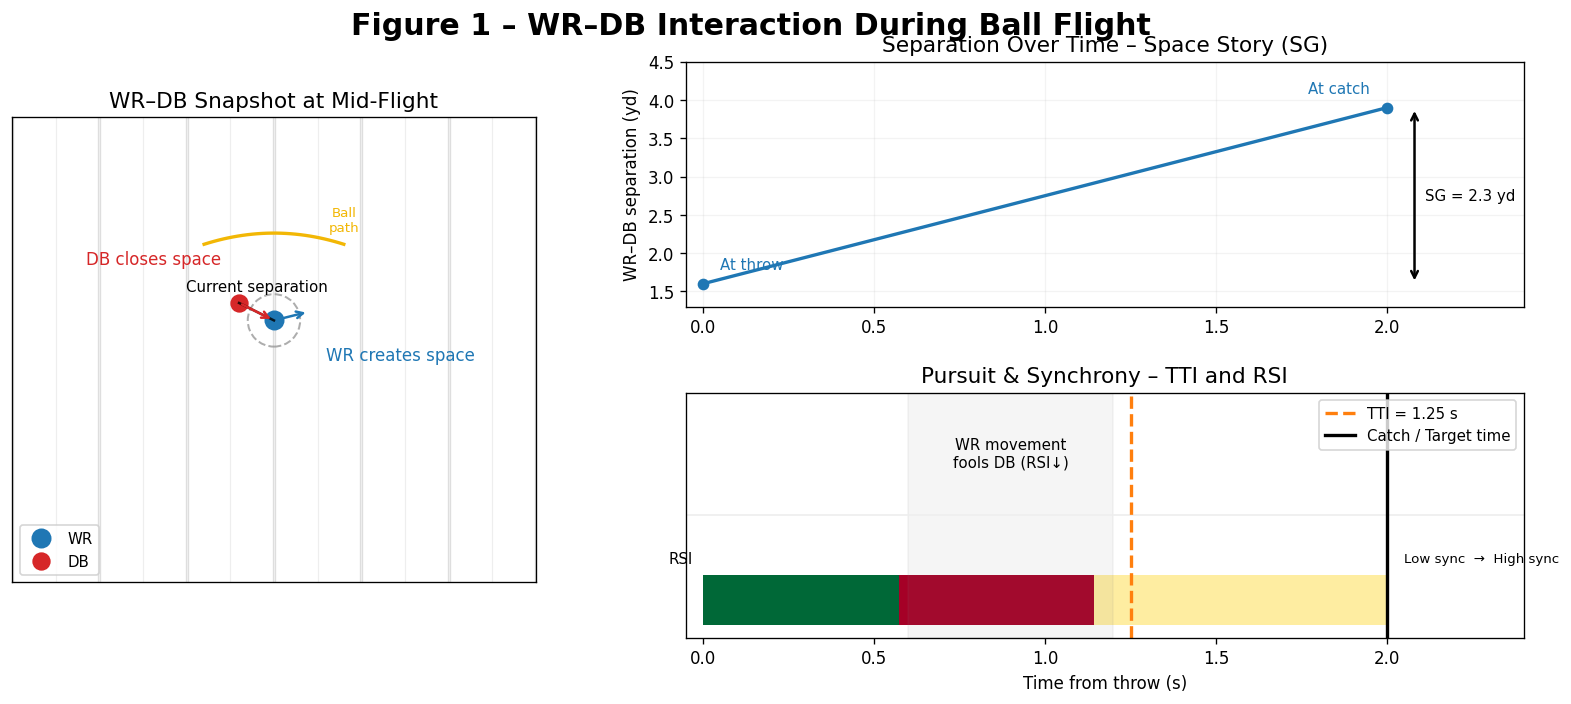

Saved figure1_interaction_map_clean_v2.png


In [ ]:
"""
Figure 1 – WR–DB Interaction During Ball Flight
(cleaned layout, no overlapping text)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import gridspec

# -----------------------------
# 1. Dummy data for one play
# -----------------------------
t = np.linspace(0, 2.0, 21)

sep_at_throw = 1.6
sep_at_catch = 3.9
sep = np.linspace(sep_at_throw, sep_at_catch, len(t))
sg = sep_at_catch - sep_at_throw

tti = 1.25
t_catch = 2.0

RSI = np.ones_like(t) * 0.8
RSI[(t >= 0.6) & (t <= 1.2)] = 0.35
RSI[t > 1.2] = 0.55

# -----------------------------
# 2. Layout
# -----------------------------
fig = plt.figure(figsize=(14, 6), dpi=120)
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1.0, 1.6],
    height_ratios=[1.0, 1.0]
)

# NOTE: increased hspace, slightly more vertical gap on right side
plt.subplots_adjust(
    left=0.06, right=0.96,
    top=0.90, bottom=0.10,
    wspace=0.22, hspace=0.35
)

ax_field = fig.add_subplot(gs[:, 0])
ax_sep   = fig.add_subplot(gs[0, 1])
ax_tti   = fig.add_subplot(gs[1, 1])

fig.suptitle("Figure 1 – WR–DB Interaction During Ball Flight",
             fontsize=18, fontweight="bold", y=0.97)

# -----------------------------
# 3. Left: Field snapshot
# -----------------------------
ax_field.set_title("WR–DB Snapshot at Mid-Flight", fontsize=13)

ax_field.set_xlim(0, 60)
ax_field.set_ylim(0, 53.3)
ax_field.set_aspect("equal")
ax_field.set_xticks([])
ax_field.set_yticks([])

for x in range(0, 61, 10):
    ax_field.axvline(x, color="#dddddd", lw=2, zorder=0)
for x in range(0, 61, 5):
    ax_field.axvline(x, color="#eeeeee", lw=0.7, zorder=0)

wr_x, wr_y = 30, 30
db_x, db_y = 26, 32

ax_field.plot(wr_x, wr_y, "o", ms=11, color="#1f77b4", label="WR")
ax_field.plot(db_x, db_y, "o", ms=10, color="#d62728", label="DB")

ax_field.plot([wr_x, db_x], [wr_y, db_y], color="black", lw=1.5, alpha=0.8)
ax_field.text(
    (wr_x + db_x) / 2, (wr_y + db_y) / 2 + 2.0,
    "Current separation", fontsize=9,
    ha="center", va="bottom"
)

contest_circle = Circle((wr_x, wr_y), radius=3.0, edgecolor="#999999",
                        facecolor="none", ls="--", lw=1.2, alpha=0.8)
ax_field.add_patch(contest_circle)

ax_field.annotate(
    "", xy=(wr_x + 4, wr_y + 1), xytext=(wr_x, wr_y),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#1f77b4")
)
ax_field.annotate(
    "", xy=(wr_x, wr_y), xytext=(db_x, db_y),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#d62728")
)

ball_x = np.linspace(22, 38, 30)
ball_y = 40 - 0.02 * (ball_x - 30)**2
ax_field.plot(ball_x, ball_y, color="#f2b705", lw=2)
ax_field.text(ball_x[-1], ball_y[-1] + 1.2, "Ball\npath", fontsize=8,
              ha="center", va="bottom", color="#f2b705")

ax_field.text(wr_x + 6, wr_y - 4, "WR creates space", fontsize=10,
              color="#1f77b4", ha="left", va="center")
ax_field.text(db_x - 2, db_y + 5, "DB closes space", fontsize=10,
              color="#d62728", ha="right", va="center")

ax_field.legend(loc="lower left", fontsize=9, frameon=True)

# -----------------------------
# 4. Top-right: Separation (SG)
# -----------------------------
ax_sep.set_title("Separation Over Time – Space Story (SG)", fontsize=13)
ax_sep.plot(t, sep, color="#1f77b4", lw=2)

# NOTE: no x-label here – avoids overlap, bottom panel carries it
ax_sep.set_ylabel("WR–DB separation (yd)", fontsize=10)

ax_sep.scatter([0], [sep_at_throw], color="#1f77b4", zorder=5)
ax_sep.text(0.05, sep_at_throw + 0.15, "At throw",
            fontsize=9, ha="left", va="bottom", color="#1f77b4")

ax_sep.scatter([t_catch], [sep_at_catch], color="#1f77b4", zorder=5)
ax_sep.text(t_catch - 0.05, sep_at_catch + 0.15, "At catch",
            fontsize=9, ha="right", va="bottom", color="#1f77b4")

arrow_x = t_catch + 0.08
ax_sep.annotate(
    "", xy=(arrow_x, sep_at_catch), xytext=(arrow_x, sep_at_throw),
    arrowprops=dict(arrowstyle="<->", lw=1.5, color="black")
)
ax_sep.text(
    arrow_x + 0.03,
    (sep_at_throw + sep_at_catch) / 2,
    f"SG = {sg:.1f} yd",
    fontsize=9, ha="left", va="center"
)

ax_sep.set_xlim(-0.05, t_catch + 0.4)
ax_sep.set_ylim(sep_at_throw - 0.3, sep_at_catch + 0.6)
ax_sep.grid(alpha=0.15)

# -----------------------------
# 5. Bottom-right: TTI + RSI
# -----------------------------
ax_tti.set_title("Pursuit & Synchrony – TTI and RSI", fontsize=13)

ax_tti.axhline(0.5, color="#eeeeee", lw=1)

ax_tti.axvline(tti, color="#ff7f0e", lw=2, ls="--", label=f"TTI = {tti:.2f} s")
ax_tti.axvline(t_catch, color="black", lw=2, ls="-", label="Catch / Target time")

rsi_norm = (RSI - RSI.min()) / (RSI.max() - RSI.min() + 1e-6)
rsi_matrix = rsi_norm.reshape(1, -1)
extent = [t[0], t[-1], 0.05, 0.25]

ax_tti.imshow(
    rsi_matrix,
    aspect="auto",
    extent=extent,
    cmap="RdYlGn",
    origin="lower"
)

ax_tti.text(
    t[0] - 0.03, 0.32, "RSI",
    fontsize=9, ha="right", va="center"
)
ax_tti.text(
    t[-1] + 0.05, 0.32,
    "Low sync  →  High sync",
    fontsize=8, ha="left", va="center"
)

drop_start, drop_end = 0.6, 1.2
ax_tti.axvspan(drop_start, drop_end, color="grey", alpha=0.08)
ax_tti.text(
    (drop_start + drop_end) / 2, 0.75,
    "WR movement\nfools DB (RSI↓)",
    fontsize=9, ha="center", va="center"
)

ax_tti.set_xlim(-0.05, t_catch + 0.4)
ax_tti.set_ylim(0.0, 1.0)
ax_tti.set_yticks([])

# ONLY this panel has the shared x-label
ax_tti.set_xlabel("Time from throw (s)", fontsize=10)

ax_tti.legend(loc="upper right", fontsize=9, frameon=True)

# -----------------------------
# 6. Save & show
# -----------------------------
plt.savefig("figure1_interaction_map_clean_v2.png", bbox_inches="tight")
plt.show()
print("Saved figure1_interaction_map_clean_v2.png")


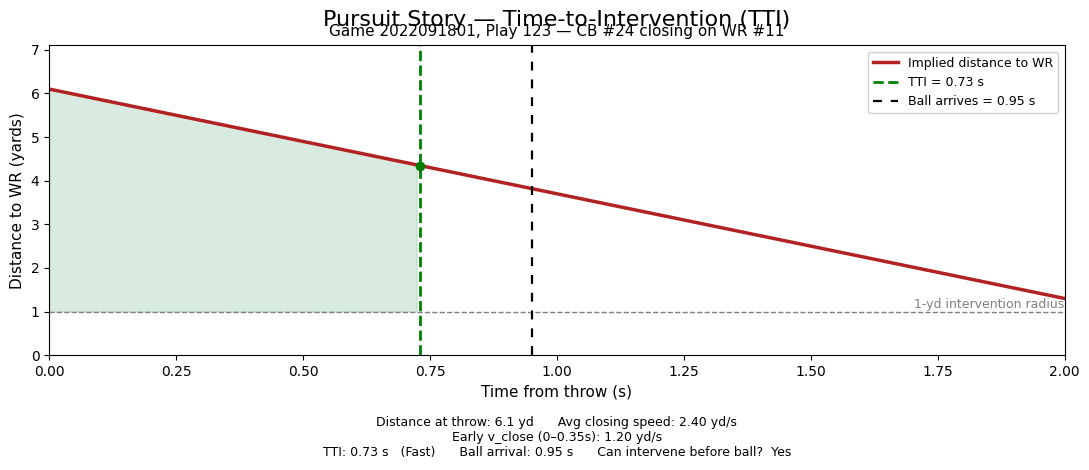

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dummy play-level TTI numbers
# -----------------------------
game_id = 2022091801
play_id = 123
db_label = "CB #24"
wr_label = "WR #11"

distance_throw = 6.1      # yards at throw
avg_v_close = 2.4         # yd/s, average closing speed
early_v_close = 1.2       # yd/s in first 0.35s (for text only)
tti = 0.73                # seconds
ball_arrival = 0.95       # seconds, time to ball arrival at WR

# Time axis for implied distance curve
t_max = 2.0
t = np.linspace(0, t_max, 200)
dist = np.maximum(distance_throw - avg_v_close * t, 0.0)

# -----------------------------
# Figure & layout
# -----------------------------
fig = plt.figure(figsize=(11, 4.8))

# Use a GridSpec: top = main plot, bottom = summary text
gs = fig.add_gridspec(4, 1, height_ratios=[4, 0.1, 0.1, 1])
ax = fig.add_subplot(gs[0:3, 0])
text_ax = fig.add_subplot(gs[3, 0])
text_ax.axis("off")

# -----------------------------
# Main TTI plot
# -----------------------------
# Implied distance line
line_main, = ax.plot(
    t, dist,
    color="#b22222", linewidth=2.5,
    label="Implied distance to WR"
)

# Shade pursuit area up to TTI
mask_tti = t <= tti
ax.fill_between(
    t[mask_tti], dist[mask_tti], 1.0,
    color="#2e8b57", alpha=0.18
)

# 1-yd intervention radius
ax.axhline(
    1.0, color="gray", linestyle="--", linewidth=1
)
ax.text(
    t_max, 1.02, "1-yd intervention radius",
    ha="right", va="bottom", fontsize=9, color="gray"
)

# Vertical line at TTI
ax.axvline(
    tti, color="green", linestyle="--", linewidth=2,
    label=f"TTI = {tti:.2f} s"
)
ax.scatter(
    [tti], [np.interp(tti, t, dist)],
    color="green", s=35, zorder=5
)

# Vertical line at ball arrival
ax.axvline(
    ball_arrival, color="black",
    linestyle=(0, (4, 4)), linewidth=1.6,
    label=f"Ball arrives = {ball_arrival:.2f} s"
)

# Axes labels & limits
ax.set_xlabel("Time from throw (s)", fontsize=11)
ax.set_ylabel("Distance to WR (yards)", fontsize=11)
ax.set_xlim(0, t_max)
ax.set_ylim(0, distance_throw + 1)

# Title & subtitle
ax.set_title(
    "Pursuit Story — Time-to-Intervention (TTI)",
    fontsize=16, pad=14
)
subtitle = f"Game {game_id}, Play {play_id} — {db_label} closing on {wr_label}"
ax.text(
    0.5, 1.02, subtitle,
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=11
)

# Legend inside axes, but away from lines
ax.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    framealpha=0.9
)

# -----------------------------
# Summary text BELOW the plot
# -----------------------------
can_intervene = "Yes" if tti < ball_arrival else "No"

summary_lines = [
    f"Distance at throw: {distance_throw:.1f} yd      "
    f"Avg closing speed: {avg_v_close:.2f} yd/s",
    f"Early v_close (0–0.35s): {early_v_close:.2f} yd/s",
    f"TTI: {tti:.2f} s   (Fast)      "
    f"Ball arrival: {ball_arrival:.2f} s      "
    f"Can intervene before ball?  {can_intervene}"
]

summary_text = "\n".join(summary_lines)

text_ax.text(
    0.5, 0.5, summary_text,
    ha="center", va="center",
    fontsize=9
)

plt.tight_layout()
plt.show()


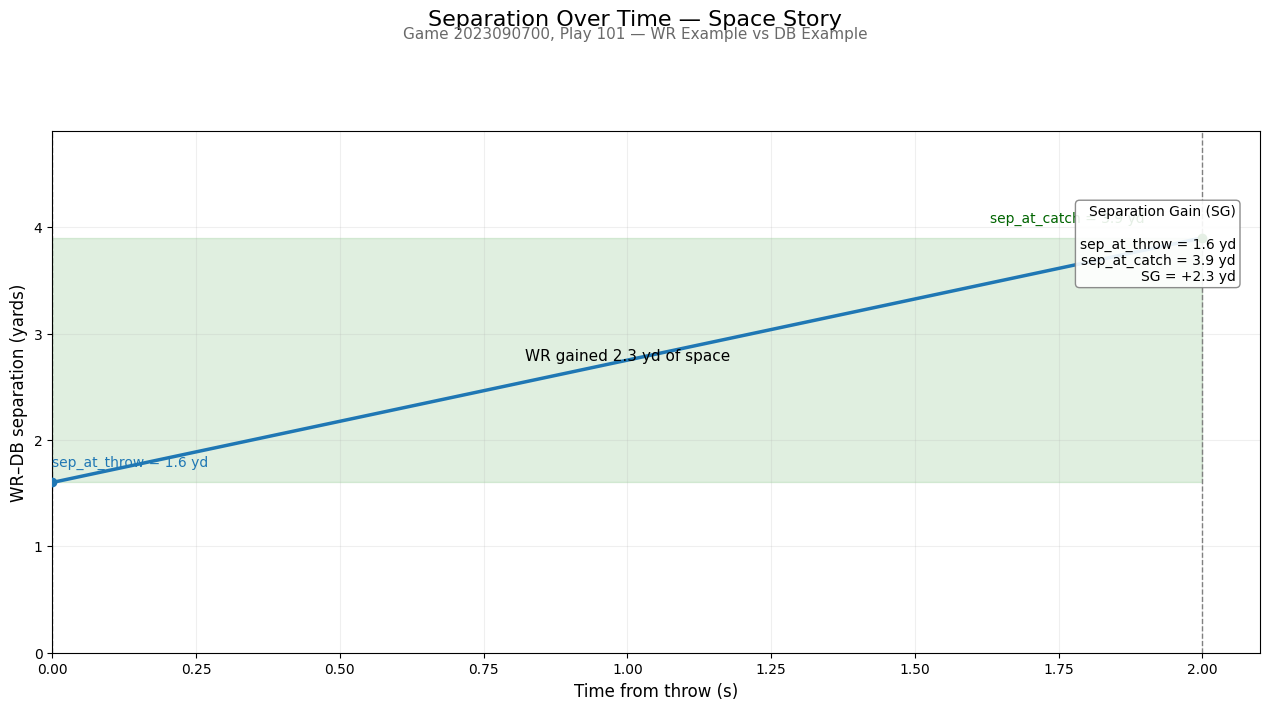

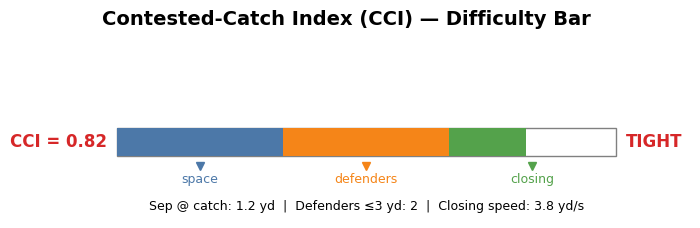

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dummy Play Data (one play)
# -----------------------------
time_to_land = 2.0  # seconds
time = np.linspace(0, time_to_land, 20)

sep_at_throw = 1.6
sep_at_catch = 3.9
sep_gain = sep_at_catch - sep_at_throw

# Implied smooth separation curve
separation = np.linspace(sep_at_throw, sep_at_catch, len(time))

# Metadata
game_id = 2023090700
play_id = 101
wr_name = "WR Example"
db_name = "DB Example"

# -----------------------------
# Create Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12.8, 7.2))

# Separation curve
ax.plot(time, separation, color="#1f77b4", linewidth=2.5)

# Throw & Catch markers
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.axvline(time_to_land, linestyle="--", color="gray", linewidth=1)

ax.scatter([0], [sep_at_throw], color="#1f77b4", zorder=3)
ax.scatter(
    [time_to_land],
    [sep_at_catch],
    color="darkgreen" if sep_gain > 0 else "darkred",
    zorder=3
)

# Shaded SG region
ax.fill_between(
    time,
    sep_at_throw,
    sep_at_catch,
    color="green" if sep_gain > 0 else "red",
    alpha=0.12
)

# Axes labels
ax.set_xlabel("Time from throw (s)", fontsize=12)
ax.set_ylabel("WR–DB separation (yards)", fontsize=12)

# Axis limits
ax.set_xlim(0, time_to_land + 0.1)
ax.set_ylim(0, max(sep_at_throw, sep_at_catch) + 1)

# Grid
ax.grid(True, alpha=0.2)

# -----------------------------
# Annotations
# -----------------------------
ax.text(0, sep_at_throw + 0.15, f"sep_at_throw = {sep_at_throw:.1f} yd",
        fontsize=10, color="#1f77b4")

ax.text(time_to_land - 0.1, sep_at_catch + 0.15,
        f"sep_at_catch = {sep_at_catch:.1f} yd",
        fontsize=10, ha="right", color="darkgreen")

ax.text(time_to_land / 2, (sep_at_throw + sep_at_catch) / 2,
        f"WR gained {sep_gain:.1f} yd of space",
        fontsize=11, ha="center")

# SG summary box
sg_text = (
    "Separation Gain (SG)\n\n"
    f"sep_at_throw = {sep_at_throw:.1f} yd\n"
    f"sep_at_catch = {sep_at_catch:.1f} yd\n"
    f"SG = {sep_gain:+.1f} yd"
)
ax.text(
    0.98, 0.86,
    sg_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# -----------------------------
# Title & Subtitle (no overlap)
# -----------------------------
fig.suptitle(
    "Separation Over Time — Space Story",
    fontsize=16,
    y=0.98
)

fig.text(
    0.5, 0.94,
    f"Game {game_id}, Play {play_id} — {wr_name} vs {db_name}",
    ha="center",
    fontsize=11,
    color="dimgray"
)

# Layout control
plt.tight_layout(rect=[0, 0, 1, 0.88])

# -----------------------------
# Show / Save
# -----------------------------
plt.show()
# plt.savefig("figure_sg_space_story.png", dpi=150, bbox_inches="tight")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Dummy CCI play inputs
# -----------------------------
cci = 0.82                      # overall CCI (0–1)
sep_at_catch = 1.2              # yards
defenders_within_3 = 2
closing_speed = 3.8             # yd/s

# Category thresholds (you can tweak)
if cci < 0.40:
    cat_label = "OPEN"
    cat_color = "#2ca02c"      # green
elif cci < 0.75:
    cat_label = "MODERATE"
    cat_color = "#ff7f0e"      # amber
else:
    cat_label = "TIGHT"
    cat_color = "#d62728"      # red

# -----------------------------
# Figure + axis
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 2.4))
fig.suptitle("Contested-Catch Index (CCI) — Difficulty Bar",
             fontsize=14, fontweight="bold", y=0.93)

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0.0, 1.0)
ax.axis("off")  # hide axes

# -----------------------------
# Segment definition (space / defenders / closing)
# -----------------------------
segments = [
    ("space",     0.00, 1/3,  "#4C78A8"),  # blue
    ("defenders", 1/3,  2/3,  "#F58518"),  # orange
    ("closing",   2/3,  1.00, "#54A24B")   # green
]

bar_y = 0.5       # vertical center of bar
bar_h = 0.18      # bar height

# Outer bar outline (full 0–1 range)
outer = Rectangle((0, bar_y - bar_h/2),
                  1.0, bar_h,
                  linewidth=1.0,
                  edgecolor="gray",
                  facecolor="none")
ax.add_patch(outer)

# Fill each component segment up to CCI
for label, x0, x1, color in segments:
    # how far into this segment does CCI reach?
    fill_end = min(cci, x1)
    if fill_end > x0:  # only draw if CCI passes the start of this segment
        width = fill_end - x0
        seg_rect = Rectangle((x0, bar_y - bar_h/2),
                             width, bar_h,
                             linewidth=0,
                             facecolor=color)
        ax.add_patch(seg_rect)

# -----------------------------
# Left "CCI =" label
# -----------------------------
ax.text(-0.02, bar_y,
        f"CCI = {cci:.2f}",
        ha="right", va="center",
        fontsize=12, fontweight="bold",
        color=cat_color)

# -----------------------------
# Right category label
# -----------------------------
ax.text(1.02, bar_y,
        cat_label,
        ha="left", va="center",
        fontsize=12, fontweight="bold",
        color=cat_color)

# -----------------------------
# Component markers under bar
# -----------------------------
marker_y = bar_y - bar_h/2 - 0.07
label_y  = marker_y - 0.04

for label, x0, x1, color in segments:
    xpos = (x0 + x1) / 2
    # small triangle marker
    ax.plot(xpos, marker_y, marker='v', markersize=6,
            color=color, clip_on=False)
    # text label
    ax.text(xpos, label_y, label,
            ha="center", va="top",
            fontsize=9, color=color)

# -----------------------------
# Footer line with context
# -----------------------------
footer_text = (
    f"Sep @ catch: {sep_at_catch:.1f} yd  |  "
    f"Defenders ≤3 yd: {defenders_within_3}  |  "
    f"Closing speed: {closing_speed:.1f} yd/s"
)

ax.text(0.5, 0.08,
        footer_text,
        ha="center", va="center",
        fontsize=9, color="black")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


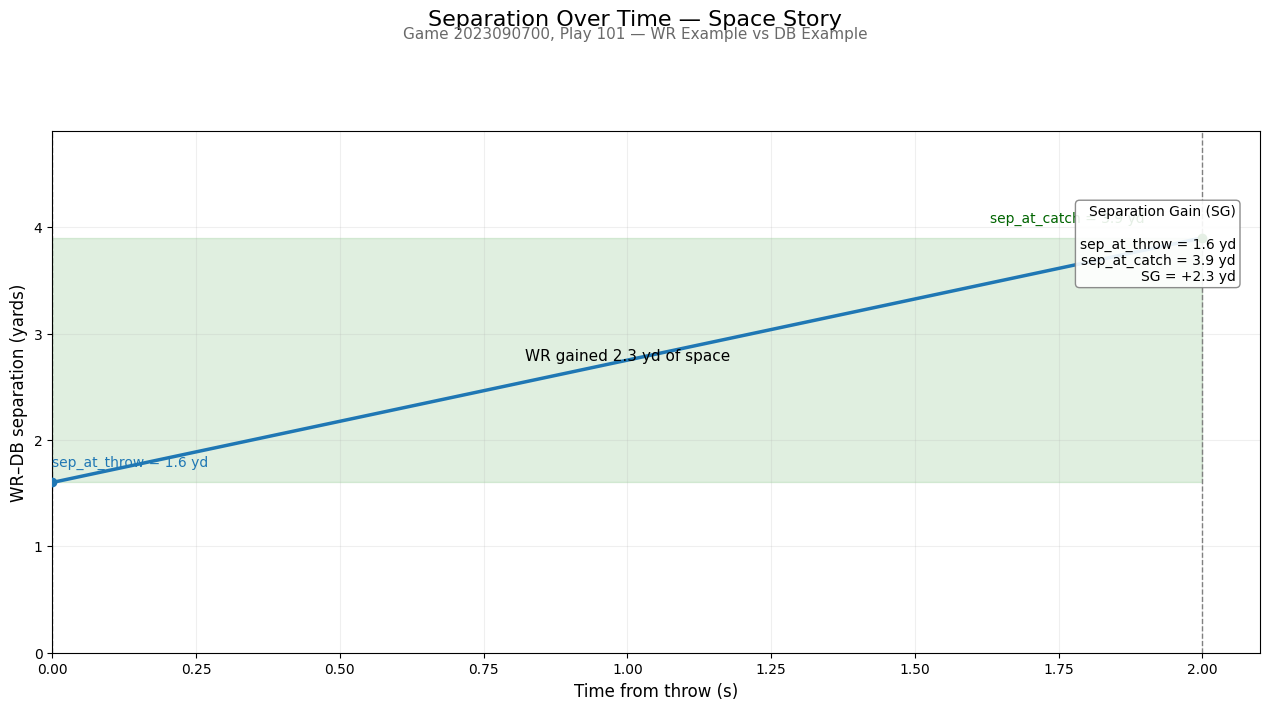

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dummy Play Data (one play)
# -----------------------------
time_to_land = 2.0  # seconds
time = np.linspace(0, time_to_land, 20)

sep_at_throw = 1.6
sep_at_catch = 3.9
sep_gain = sep_at_catch - sep_at_throw

# Implied smooth separation curve
separation = np.linspace(sep_at_throw, sep_at_catch, len(time))

# Metadata
game_id = 2023090700
play_id = 101
wr_name = "WR Example"
db_name = "DB Example"

# -----------------------------
# Create Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12.8, 7.2))

# Separation curve
ax.plot(time, separation, color="#1f77b4", linewidth=2.5)

# Throw & Catch markers
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.axvline(time_to_land, linestyle="--", color="gray", linewidth=1)

ax.scatter([0], [sep_at_throw], color="#1f77b4", zorder=3)
ax.scatter(
    [time_to_land],
    [sep_at_catch],
    color="darkgreen" if sep_gain > 0 else "darkred",
    zorder=3
)

# Shaded SG region
ax.fill_between(
    time,
    sep_at_throw,
    sep_at_catch,
    color="green" if sep_gain > 0 else "red",
    alpha=0.12
)

# Axes labels
ax.set_xlabel("Time from throw (s)", fontsize=12)
ax.set_ylabel("WR–DB separation (yards)", fontsize=12)

# Axis limits
ax.set_xlim(0, time_to_land + 0.1)
ax.set_ylim(0, max(sep_at_throw, sep_at_catch) + 1)

# Grid
ax.grid(True, alpha=0.2)

# -----------------------------
# Annotations
# -----------------------------
ax.text(0, sep_at_throw + 0.15, f"sep_at_throw = {sep_at_throw:.1f} yd",
        fontsize=10, color="#1f77b4")

ax.text(time_to_land - 0.1, sep_at_catch + 0.15,
        f"sep_at_catch = {sep_at_catch:.1f} yd",
        fontsize=10, ha="right", color="darkgreen")

ax.text(time_to_land / 2, (sep_at_throw + sep_at_catch) / 2,
        f"WR gained {sep_gain:.1f} yd of space",
        fontsize=11, ha="center")

# SG summary box
sg_text = (
    "Separation Gain (SG)\n\n"
    f"sep_at_throw = {sep_at_throw:.1f} yd\n"
    f"sep_at_catch = {sep_at_catch:.1f} yd\n"
    f"SG = {sep_gain:+.1f} yd"
)
ax.text(
    0.98, 0.86,
    sg_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# -----------------------------
# Title & Subtitle (no overlap)
# -----------------------------
fig.suptitle(
    "Separation Over Time — Space Story",
    fontsize=16,
    y=0.98
)

fig.text(
    0.5, 0.94,
    f"Game {game_id}, Play {play_id} — {wr_name} vs {db_name}",
    ha="center",
    fontsize=11,
    color="dimgray"
)

# Layout control
plt.tight_layout(rect=[0, 0, 1, 0.88])

# -----------------------------
# Show / Save
# -----------------------------
plt.show()
# plt.savefig("figure_sg_space_story.png", dpi=150, bbox_inches="tight")
